In [1]:
import numpy as np
import pandas as pd
import re
pd.set_option('display.max_colwidth',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

In [2]:
df=pd.read_csv('C:/Users/8429s/OneDrive/Desktop/Placement/Projects/Real Estate Price Prediction and Recommendation System/Data_Clean/flats_and_house_v1.csv')

In [3]:
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,house,independent,sector 4,0.58,86567.0,67.0,Plot area 67(6.22 sq.m.),2,2,1,"pooja room,others",2.0,West,5 to 10 Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', 'State bank ATM', 'Prateek Nursing Home And Polyclinic', 'Sneh Hospital Gurgaon', 'Kr Dental Hub', 'Dr. Hitesh Dawar', 'Jain Sant Phool Chand Ji Charitable Hospital', 'Sarvodya Hospital', 'Shree Krishna Hospital Gurgaon', 'Dr. Sindhu Clinic', 'Bhardwaj Hospital', 'Dr. Mittal Clinic', 'Jiya Clinic', 'Dr. Ashok Jain', 'Gurgaon Eye Centre', 'Yashroop Medical Centre', ""Dr. Anurag's Child Care Clinic"", 'R K Hospital Gurgaon', 'Pearl Dental Clinic', 'Esic Hospital Gurugram', 'Aryan Hospital', 'Taneja Hospital', 'Chirag Hospital Pvt. Ltd', 'D.R. Rajnis Gupta Clinic', 'Geeta Nursing Home Gurgaon', 'Sparsh Hospital Gurgaon', 'Ravi Clinic and Health Care Centre', 'Dr. Agya Ram Sharma Clinic', 'Bhatnagar Maternity and Nursing Home', 'GH Gurgaon', 'Chiranjiv Hospital', 'Dr. Madan Clinic', 'Dr. Sarvejeet Singh', 'Bindal Clinic', 'Centre For Sight Gurgaon New Railway Road', 'Dev Man Kathuria Clinic', 'Swastik Maternity and Medical Centre', 'Kidney Clinic', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'State bank of india', 'Pizza Hut', 'St. Michaels Sr. Sec. School', 'Dronacharya Government College', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station']","['1 Fan', '1 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",['Water Storage']


In [4]:
#we will focus on areaWithType,additional room,agePossession,furnishDetails,features

## 1 AreaWithType

In [5]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
3138,0.75,1081.0,Built Up area: 1081 (100.43 sq.m.)
3049,2.45,2132.0,Super Built up area 2132(198.07 sq.m.)Built Up area: 1800 sq.ft. (167.23 sq.m.)Carpet area: 1500 sq.ft. (139.35 sq.m.)
298,10.50,3240.0,Plot area 360(301.01 sq.m.)
2305,2.35,1450.0,Super Built up area 1650(153.29 sq.m.)Built Up area: 1500 sq.ft. (139.35 sq.m.)Carpet area: 1450 sq.ft. (134.71 sq.m.)
1300,6.20,2997.0,Super Built up area 2997(278.43 sq.m.)


In [6]:
# Function to extract superbuilt up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)',text)
    if match:
        return float(match.group(1))
    return None

In [7]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [8]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [9]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [10]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
882,1.18,flat,1383.0,Super Built up area 1383(128.48 sq.m.),1383.0,NaN,NaN
3364,2.35,flat,2400.0,Carpet area: 2400 (222.97 sq.m.),NaN,NaN,2400.0
495,1.24,flat,1741.0,Super Built up area 1741(161.74 sq.m.)Built Up area: 1730 sq.ft. (160.72 sq.m.)Carpet area: 1720 sq.ft. (159.79 sq.m.),1741.0,1730.0,1720.0
3417,18.90,house,4518.0,Plot area 502(419.74 sq.m.),NaN,NaN,NaN
1717,5.20,house,5200.0,Built Up area: 5200 (483.1 sq.m.)Carpet area: 4000 sq.ft. (371.61 sq.m.),NaN,5200.0,4000.0


In [11]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [12]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,0.58,house,67.0,Plot area 67(6.22 sq.m.),NaN,NaN,NaN
18,0.34,house,270.0,Plot area 270(25.08 sq.m.),NaN,NaN,NaN
21,11.75,house,2844.0,Plot area 316(264.22 sq.m.),NaN,NaN,NaN
28,2.50,house,1400.0,Plot area 1400(130.06 sq.m.)Built Up area: 1850 sq.ft. (171.87 sq.m.),NaN,1850.0,NaN
34,4.50,house,1350.0,Plot area 150(125.42 sq.m.),NaN,NaN,NaN


In [13]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                147
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2616
carpet_area            1859
dtype: int64

In [14]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [15]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,0.58,house,67.0,Plot area 67(6.22 sq.m.),NaN,NaN,NaN
18,0.34,house,270.0,Plot area 270(25.08 sq.m.),NaN,NaN,NaN
21,11.75,house,2844.0,Plot area 316(264.22 sq.m.),NaN,NaN,NaN
34,4.50,house,1350.0,Plot area 150(125.42 sq.m.),NaN,NaN,NaN
38,10.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN


In [16]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [17]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [18]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [19]:
all_nan_df.head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,0.58,house,67.0,Plot area 67(6.22 sq.m.),NaN,67.0,NaN
18,0.34,house,270.0,Plot area 270(25.08 sq.m.),NaN,270.0,NaN
21,11.75,house,2844.0,Plot area 316(264.22 sq.m.),NaN,316.0,NaN
34,4.50,house,1350.0,Plot area 150(125.42 sq.m.),NaN,150.0,NaN
38,10.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.0,NaN


In [20]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [21]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [22]:
all_nan_df.sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1137,4.00,house,1836.0,Plot area 204(170.57 sq.m.),NaN,1836.0,NaN
3189,3.55,house,1449.0,Plot area 161(134.62 sq.m.),NaN,1449.0,NaN
1230,2.20,house,1800.0,Plot area 1800(167.23 sq.m.),NaN,1800.0,NaN
1823,4.75,house,2340.0,Plot area 260(217.39 sq.m.),NaN,2340.0,NaN
2538,0.49,house,1150.0,Plot area 1150(106.84 sq.m.),NaN,1150.0,NaN


In [23]:
# update the original dataframe
df.update(all_nan_df)

In [24]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                147
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2070
carpet_area            1859
dtype: int64

In [25]:
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,house,independent,sector 4,0.58,86567.0,67.0,Plot area 67(6.22 sq.m.),2,2,1,"pooja room,others",2.0,West,5 to 10 Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', 'State bank ATM', 'Prateek Nursing Home And Polyclinic', 'Sneh Hospital Gurgaon', 'Kr Dental Hub', 'Dr. Hitesh Dawar', 'Jain Sant Phool Chand Ji Charitable Hospital', 'Sarvodya Hospital', 'Shree Krishna Hospital Gurgaon', 'Dr. Sindhu Clinic', 'Bhardwaj Hospital', 'Dr. Mittal Clinic', 'Jiya Clinic', 'Dr. Ashok Jain', 'Gurgaon Eye Centre', 'Yashroop Medical Centre', ""Dr. Anurag's Child Care Clinic"", 'R K Hospital Gurgaon', 'Pearl Dental Clinic', 'Esic Hospital Gurugram', 'Aryan Hospital', 'Taneja Hospital', 'Chirag Hospital Pvt. Ltd', 'D.R. Rajnis Gupta Clinic', 'Geeta Nursing Home Gurgaon', 'Sparsh Hospital Gurgaon', 'Ravi Clinic and Health Care Centre', 'Dr. Agya Ram Sharma Clinic', 'Bhatnagar Maternity and Nursing Home', 'GH Gurgaon', 'Chiranjiv Hospital', 'Dr. Madan Clinic', 'Dr. Sarvejeet Singh', 'Bindal Clinic', 'Centre For Sight Gurgaon New Railway Road', 'Dev Man Kathuria Clinic', 'Swastik Maternity and Medical Centre', 'Kidney Clinic', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'State bank of india', 'Pizza Hut', 'St. Michaels Sr. Sec. School', 'Dronacharya Government College', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station']","['1 Fan', '1 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",['Water Storage'],NaN,67.0,NaN


## 2. Additional Room

In [26]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1587
servant room                                      705
study room                                        250
others                                            225
pooja room                                        165
store room                                         99
study room,servant room                            99
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,store room                              15
servant room,

In [27]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [28]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
3621,not available,0,0,0,0,0
3734,not available,0,0,0,0,0
13,others,0,0,0,0,1
2976,"pooja room,study room,servant room,store room",1,1,1,1,0
2558,others,0,0,0,0,1


## 3. agePossession

In [29]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec 2023                20
By 2023                 19
By 2024                 17
Dec 2024                15
Mar 2024                14
Aug 2023                 7
Oct 2024                 7
Jan 2024                 7
Dec 2025                 7
Jun 2024                 5
Nov 2023                 5
By 2025                  4
Jul 2024                 4
Sep 2023                 4
Aug 2024                 4
Feb 2024                 3
Oct 2023                 3
May 2024                 3
Nov 2024                 3
Jan 2025                 3
Mar 2025                 2
By 2027                  2
Dec-23                   2
Dec 2026                 2
Jul 2025                 2
Sep 2025                 2
Jul 2027                 2
Jan 2026                 2
Jun 2027      

In [30]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [31]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [32]:
df['agePossession'].value_counts()

agePossession
Relatively New        1676
New Property           626
Moderately Old         575
Undefined              341
Old Property           310
Under Construction     275
Name: count, dtype: int64

## 4. Furnish Details

In [33]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
2045,[],['Private Garden / Terrace']
969,"['7 Wardrobe', '1 Water Purifier', '6 Fan', '1 Exhaust Fan', '5 Geyser', '1 Stove', '20 Light', '6 AC', '1 Chimney', '1 Modular Kitchen', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
3784,NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Park', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']"
2277,"['3 Wardrobe', '1 Exhaust Fan', '3 Geyser', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Fan', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Lift(s)', 'Piped-gas', 'Club house / Community Center', 'Rain Water Harvesting']"
1325,"['6 Fan', '1 Fridge', '1 Exhaust Fan', '3 Geyser', '20 Light', '5 AC', '1 TV', '1 Modular Kitchen', '1 Chimney', '1 Curtains', '2 Bed', '4 Wardrobe', 'No Dining Table', 'No Microwave', 'No Sofa', 'No Stove', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"


In [34]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [35]:
furnishings_df.shape

(3803, 19)

In [36]:
furnishings_df.shape

(3803, 19)

In [37]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\8429s\AppData\Local\Temp\ipykernel_1152\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [38]:
furnishings_df.sample(5)

,Bed,Stove,Sofa,Curtains,Water Purifier,Fridge,Light,Dining Table,TV,Microwave,Wardrobe,Washing Machine,Fan,Exhaust Fan,AC,Chimney,Geyser,Modular Kitchen
2469,0,1,0,0,0,0,4,0,0,0,2,0,4,1,0,1,0,1
1880,0,0,0,1,0,0,10,0,0,0,4,0,5,1,0,0,4,0
2579,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2624,0,0,0,0,0,0,6,0,0,0,3,0,4,0,0,0,0,0
2327,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [39]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [40]:
scaler=StandardScaler()
scale_data=scaler.fit_transform(furnishings_df)

In [41]:
wcss_reduced=[]

for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(scale_data)
    wcss_reduced.append(kmeans.inertia_)

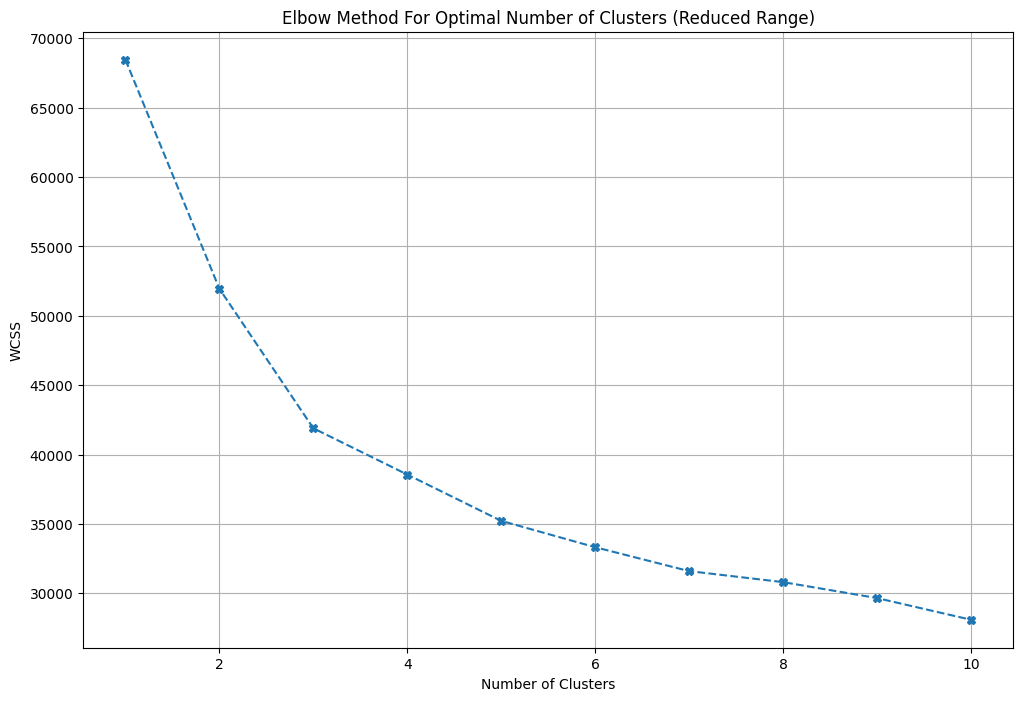

In [42]:
plt.figure(figsize=(12,8))
plt.plot(range(1,11),wcss_reduced,marker='X',linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [43]:
n_clusters=3
#Fit the Kmeans Model
kmeans=KMeans(n_clusters=3,init='k-means++',random_state=42)
kmeans.fit(scale_data)
#predict the cluster assignment for each row

cluster_assignment=kmeans.predict(scale_data)


In [48]:
df = df.iloc[:,:-18]

In [50]:
df['furnishing_type'] = cluster_assignment

In [53]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
877,"['6 Fan', '1 Fridge', '1 Exhaust Fan', '1 Dining Table', '5 Geyser', '1 Stove', '5 Light', '1 Modular Kitchen', '1 Curtains', '3 TV', '1 Chimney', '5 AC', '4 Bed', '5 Wardrobe', '1 Sofa', 'No Microwave', 'No Washing Machine', 'No Water Purifier']",0
149,"['3 Fan', '1 Exhaust Fan', '16 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",2
706,"['14 Bed', '14 Wardrobe', '1 Water Purifier', '1 Fridge', '14 AC', '14 TV', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Sofa', 'No Stove', 'No Washing Machine']",0
2814,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",1
1620,[],1


In [54]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type
0,house,independent,sector 4,0.58,86567.0,67.0,Plot area 67(6.22 sq.m.),2,2,1,"pooja room,others",2.0,West,Moderately Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', 'State bank ATM', 'Prateek Nursing Home And Polyclinic', 'Sneh Hospital Gurgaon', 'Kr Dental Hub', 'Dr. Hitesh Dawar', 'Jain Sant Phool Chand Ji Charitable Hospital', 'Sarvodya Hospital', 'Shree Krishna Hospital Gurgaon', 'Dr. Sindhu Clinic', 'Bhardwaj Hospital', 'Dr. Mittal Clinic', 'Jiya Clinic', 'Dr. Ashok Jain', 'Gurgaon Eye Centre', 'Yashroop Medical Centre', ""Dr. Anurag's Child Care Clinic"", 'R K Hospital Gurgaon', 'Pearl Dental Clinic', 'Esic Hospital Gurugram', 'Aryan Hospital', 'Taneja Hospital', 'Chirag Hospital Pvt. Ltd', 'D.R. Rajnis Gupta Clinic', 'Geeta Nursing Home Gurgaon', 'Sparsh Hospital Gurgaon', 'Ravi Clinic and Health Care Centre', 'Dr. Agya Ram Sharma Clinic', 'Bhatnagar Maternity and Nursing Home', 'GH Gurgaon', 'Chiranjiv Hospital', 'Dr. Madan Clinic', 'Dr. Sarvejeet Singh', 'Bindal Clinic', 'Centre For Sight Gurgaon New Railway Road', 'Dev Man Kathuria Clinic', 'Swastik Maternity and Medical Centre', 'Kidney Clinic', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'State bank of india', 'Pizza Hut', 'St. Michaels Sr. Sec. School', 'Dronacharya Government College', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station']","['1 Fan', '1 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",['Water Storage'],NaN,67.0,NaN,0,0,0,1,1,1
1,flat,emaar mgf palm hills,sector 77,1.25,8620.0,1450.0,Super Built up area 1450(134.71 sq.m.)Carpet area: 1177 sq.ft. (109.35 sq.m.),3,4,3,"study room,servant room",3.0,North,Relatively New,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Sohna Road', 'Narayana e Techno School', 'DPG Institute of Technology', 'Medeor Hospital, Manesar', 'Indira Gandhi International Airport', 'IMT Manesar', 'Hyatt Regency Gurgaon', 'De Adventure Park']","['1 Wardrobe', '1 Geyser', '1 Light', '1 AC', '1 Chimney', '1 Modular Kitchen', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",1450.0,NaN,1177.0,1,1,0,0,0,1
2,flat,chd avenue,sector 71,1.00,6734.0,1485.0,Super Built up area 1485(137.96 sq.m.),3,3,3+,not available,3.0,North,Relatively New,"['Huda City Centre', 'Apna Mart', 'Rajiv Chowk', 'Sohna Road', 'IFFCO Chowk', 'Medanta Hospital', 'Max Hospital, Gurugram', 'IGI Airport', 'HDFC Bank', 'Candor Park', 'Marriott Courtyard', 'Radisson Suites', 'Park Plaza', 'Flipkart Warehouse', 'Sadar Police Station']","['2 Wardrobe', '4 Fan', '1 Exhaust Fan', '4 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",['Visitor Parking'],1485.0,NaN,NaN,0,0,0,0,0,2
3,flat,ild grand,sector 37c,1.20,6593.0,1820.0,Super Built up area 1820(169.08 sq.m.),3,3,3,not available,7.0,NaN,Under Construction,"['The Esplanade Mall', 'Dwarka Expy, Sector 88', 'Green Field Public School', 'SGT UNIVERSITY', 'K.D. Hospital', 'Indira Gandhi Intl Airport']",NaN,"['Lift(s)', 'Swimming Pool', 'Park', 'Fitness Centre / GYM', 'Club house / Community Center']",1820.0,NaN,NaN,0,0,0,0,0,1
4,flat,dlf the ultima,sector 81,2.20,10461.0,2103.0,Su

## 5.features

In [55]:
df[['society','features']].sample(5)

,society,features
1347,independent,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'Park', 'Visitor Parking', 'Security Personnel', 'Waste Disposal', 'Rain Water Harvesting']"
1784,ats tourmaline,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
1412,tulip purple,"['Security / Fire Alarm', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
1964,godrej icon,"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
2219,spaze privy at,"['Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']"


In [56]:
df['features'].isnull().sum()

np.int64(635)

In [58]:
import pandas as pd
app_df=pd.read_csv('C:/Users/8429s/OneDrive/Desktop/Placement/Projects/Real Estate Price Prediction and Recommendation System/Data/appartments.csv')
app_df.head(1)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"


In [59]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [60]:
temp_df = df[df['features'].isnull()]

In [61]:
temp_df.shape

(635, 26)

In [62]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [63]:
x

0                                                                                                                                                                                   NaN
1                                                                                                                                                                                   NaN
2                                                                                                                                                                                   NaN
3                                                                                                                                                                                   NaN
4                                                                                                                                                                                   NaN
5                                                                               

In [64]:
df.loc[temp_df.index,'features'] = x.values

In [65]:
df['features'].isnull().sum()

np.int64(481)

In [67]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [68]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)


In [69]:
df['luxury_score'] = luxury_score

In [70]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,house,independent,sector 4,0.58,86567.0,67.0,Plot area 67(6.22 sq.m.),2,2,1,"pooja room,others",2.0,West,Moderately Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', 'State bank ATM', 'Prateek Nursing Home And Polyclinic', 'Sneh Hospital Gurgaon', 'Kr Dental Hub', 'Dr. Hitesh Dawar', 'Jain Sant Phool Chand Ji Charitable Hospital', 'Sarvodya Hospital', 'Shree Krishna Hospital Gurgaon', 'Dr. Sindhu Clinic', 'Bhardwaj Hospital', 'Dr. Mittal Clinic', 'Jiya Clinic', 'Dr. Ashok Jain', 'Gurgaon Eye Centre', 'Yashroop Medical Centre', ""Dr. Anurag's Child Care Clinic"", 'R K Hospital Gurgaon', 'Pearl Dental Clinic', 'Esic Hospital Gurugram', 'Aryan Hospital', 'Taneja Hospital', 'Chirag Hospital Pvt. Ltd', 'D.R. Rajnis Gupta Clinic', 'Geeta Nursing Home Gurgaon', 'Sparsh Hospital Gurgaon', 'Ravi Clinic and Health Care Centre', 'Dr. Agya Ram Sharma Clinic', 'Bhatnagar Maternity and Nursing Home', 'GH Gurgaon', 'Chiranjiv Hospital', 'Dr. Madan Clinic', 'Dr. Sarvejeet Singh', 'Bindal Clinic', 'Centre For Sight Gurgaon New Railway Road', 'Dev Man Kathuria Clinic', 'Swastik Maternity and Medical Centre', 'Kidney Clinic', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'State bank of india', 'Pizza Hut', 'St. Michaels Sr. Sec. School', 'Dronacharya Government College', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station']","['1 Fan', '1 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",['Water Storage'],NaN,67.0,NaN,0,0,0,1,1,1,[Water Storage],7
1,flat,emaar mgf palm hills,sector 77,1.25,8620.0,1450.0,Super Built up area 1450(134.71 sq.m.)Carpet area: 1177 sq.ft. (109.35 sq.m.),3,4,3,"study room,servant room",3.0,North,Relatively New,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Sohna Road', 'Narayana e Techno School', 'DPG Institute of Technology', 'Medeor Hospital, Manesar', 'Indira Gandhi International Airport', 'IMT Manesar', 'Hyatt Regency Gurgaon', 'De Adventure Park']","['1 Wardrobe', '1 Geyser', '1 Light', '1 AC', '1 Chimney', '1 Modular Kitchen', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",1450.0,NaN,1177.0,1,1,0,0,0,1,"[Feng Shui / Vaastu Compliant, Security / Fire Alarm, Intercom Facility, Lift(s), Maintenance Staff, Water Storage, Park, Visitor Parking]",49
2,flat,chd avenue,sector 71,1.00,6734.0,1485.0,Super Built up area 1485(137.96 sq.m.),3,3,3+,not available,3.0,North,Relatively New,"['Huda City Centre', 'Apna Mart', 'Rajiv Chowk', 'Sohna Road', 'IFFCO Chowk', 'Medanta Hospital', 'Max Hospital, Gurugram', 'IGI Airport', 'HDFC Bank', 'Candor Park', 'Marriott Courtyard', 'Radisson Suites', 'Park Plaza', 'Flipkart Warehouse', 'Sadar Police Station']","['2 Wardrobe', '4 Fan', '1 Exhaust Fan', '4 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",['Visitor Parking'],1485.0,NaN,NaN,0,0,0,0,0,2,[Visitor Parking],7
3,flat,ild grand,sector 37c,1.20,6593.0,1820.0,Super Built up area 1820(169.08 sq.m.),3,3,3,not available,7.0,NaN,Under Construction,"['The Esplanade Mall', 'Dwarka Expy, Sector 88', 'Green Field Public School', 'SGT UNIVERSITY', 'K.D. Hospital', 'In

In [71]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [72]:
df.sample(2)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
732,flat,godrej aria,sector 79,1.95,8519.0,2289.0,Super Built up area 2289(212.66 sq.m.)Carpet area: 1121 sq.ft. (104.14 sq.m.),3,4,3+,10.0,NaN,New Property,2289.0,NaN,1121.0,0,1,0,0,0,1,32
745,flat,emaar mgf the palm drive,sector 66,3.50,16470.0,2125.0,Super Built up area 2200(204.39 sq.m.)Built Up area: 2150 sq.ft. (199.74 sq.m.)Carpet area: 2125 sq.ft. (197.42 sq.m.),3,4,3,6.0,North,Relatively New,2200.0,2150.0,2125.0,0,1,0,0,0,1,68


In [73]:
df.shape

(3803, 23)

In [74]:
df.to_csv('C:/Users/8429s/OneDrive/Desktop/Placement/Projects/Real Estate Price Prediction and Recommendation System/Data_Clean/flats_and_house_v2.csv',index=False)